# 04 - Autoencoder Essence 


In [19]:
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().resolve() / '..' / 'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

for name in list(sys.modules.keys()):
    if name == 'course_project' or name.startswith('course_project.'):
        del sys.modules[name]

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data

from graph_utils import calc_p_ratio_box, draw_graph_comparison, pyg_to_networkx

from course_project.config import ExperimentConfig
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.models import create_model
from course_project.utils import resolve_device


In [20]:
seed = 2026
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

cfg = ExperimentConfig(
    run_name='autoencoder_essence_cv20_h32',
    model_type='autoencoder',
    train_dataset='../data/2340_dePablo_networks_OOL_undirected_train100.pt',
    val_dataset='../data/2340_dePablo_networks_OOL_undirected_val100.pt',
    output_root='../results',
    device='cuda',
    pos_dim=2,
    history=1,
    limit=100,
    hidden_size=64,
    n_layers=2,
    model_extras={
        'num_mlp': 3,
        'K1': 450,
        'CV': 19,
        'cv_hidden_size': 32,
        'transformer_layers': 1,
        'transformer_heads': 4,
        'transformer_dropout': 0.01,
        'edge_aggr': 'mean',
        'use_local_skip': True,
    },
    learning_rate=1e-4,
    learning_rate_decay=1.0,
    weight_decay=0.0,
    epochs=1,
    val_every=1,
    rollout_every=0,
    cv_eval_every=0,
    rollout_steps=1,
    train_rollout_steps=1,
    seed=seed,
    verbose=True,
)

ae_epochs = 10
ae_lr = 3e-4
edge_attr_loss_weight = 1.0
use_existing_ae = False
ae_ckpt_path = Path('../results/latent_essence_autoencoder_cv20_h32.pt')






In [21]:
def ae_loss_terms(model, g, cfg):
    pred_graph, _ = model.autoencode_graph(g, is_training=model.training)
    pos_loss = F.mse_loss(pred_graph.x[:, :cfg.pos_dim], g.x[:, :cfg.pos_dim])
    edge_attr_loss = F.mse_loss(pred_graph.edge_attr, g.edge_attr)
    total = pos_loss + edge_attr_loss_weight * edge_attr_loss
    return total, pos_loss, edge_attr_loss


def eval_ae_loss(model, sims, cfg, device):
    model.eval()
    totals = []
    poses = []
    edge_attrs = []
    with torch.no_grad():
        for sim in sims:
            sim_len = min(len(sim), cfg.limit)
            for t in range(sim_len):
                g = build_graph([sim[t].to(device)]).to(device)
                total, pos, edge_a = ae_loss_terms(model, g, cfg)
                totals.append(float(total.item()))
                poses.append(float(pos.item()))
                edge_attrs.append(float(edge_a.item()))
    return float(np.mean(totals)), float(np.mean(poses)), float(np.mean(edge_attrs))


def to_cpu_graph(g):
    return Data(
        x=g.x.detach().cpu(),
        edge_index=g.edge_index.detach().cpu(),
        edge_attr=g.edge_attr.detach().cpu() if g.edge_attr is not None else None,
        box=g.box if hasattr(g, 'box') else None,
        t=g.t if hasattr(g, 't') else None,
        dtype=g.x.dtype,
    )



In [22]:
device = resolve_device(cfg.device)
print('device:', device)

train_data = load_dataset(cfg.train_dataset)
val_data = load_dataset(cfg.val_dataset)

init_graph = build_graph([train_data[0][0].to(device)]).to(device)
model = create_model(
    model_type=cfg.model_type,
    init_graph=init_graph,
    pos_dim=cfg.pos_dim,
    hidden_size=cfg.hidden_size,
    n_layers=cfg.n_layers,
    extras=cfg.model_extras,
).to(device)

print(type(model).__name__)

# data scale check (normalization sanity)
s0 = train_data[0][0]
print('x std:', s0.x[:, :cfg.pos_dim].std(dim=0).detach().cpu().numpy())
print('edge_attr std:', s0.edge_attr.std(dim=0).detach().cpu().numpy())



device: cuda
Model
x std: [4.446416 4.439941]
edge_attr std: [0.992651   0.92035466 0.49740046 0.39489806]


In [ ]:
ae_train_total = []
ae_train_pos = []
ae_train_edge_attr = []
ae_val_total = []
ae_val_pos = []
ae_val_edge_attr = []

if use_existing_ae and ae_ckpt_path.exists():
    payload = torch.load(ae_ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(payload['model_state_dict'], strict=True)
    print('Loaded AE checkpoint:', ae_ckpt_path)
else:
    for p in model.parameters():
        p.requires_grad = True

    opt = torch.optim.Adam(model.parameters(), lr=ae_lr)
    print('loss weights: edge_attr=', edge_attr_loss_weight)

    for epoch in range(ae_epochs):
        model.train()
        totals = []
        poses = []
        edge_attrs = []

        for sim in train_data:
            sim_len = min(len(sim), cfg.limit)
            for t in range(sim_len):
                g = build_graph([sim[t].to(device)]).to(device)
                total, pos, edge_a = ae_loss_terms(model, g, cfg)

                opt.zero_grad()
                total.backward()
                opt.step()

                totals.append(float(total.detach().cpu().item()))
                poses.append(float(pos.detach().cpu().item()))
                edge_attrs.append(float(edge_a.detach().cpu().item()))

        tr_total = float(np.mean(totals))
        tr_pos = float(np.mean(poses))
        tr_edge_a = float(np.mean(edge_attrs))
        va_total, va_pos, va_edge_a = eval_ae_loss(model, val_data, cfg, device)

        ae_train_total.append(tr_total)
        ae_train_pos.append(tr_pos)
        ae_train_edge_attr.append(tr_edge_a)
        ae_val_total.append(va_total)
        ae_val_pos.append(va_pos)
        ae_val_edge_attr.append(va_edge_a)

        print(f'[AE {epoch + 1:03d}/{ae_epochs}] tr={tr_total:.6g} va={va_total:.6g} tr_pos={tr_pos:.6g} tr_edgeA={tr_edge_a:.6g} va_pos={va_pos:.6g} va_edgeA={va_edge_a:.6g}')

    torch.save({'model_state_dict': model.state_dict()}, ae_ckpt_path)
    print('Saved AE checkpoint:', ae_ckpt_path)



loss weights: edge_attr= 1.0
[AE 001/10] tr=0.195892 va=0.168258 tr_pos=0.0515977 tr_edgeA=0.144294 va_pos=0.00853446 va_edgeA=0.159723
[AE 002/10] tr=0.0493389 va=0.149001 tr_pos=0.00242278 tr_edgeA=0.0469161 va_pos=0.0221054 va_edgeA=0.126896


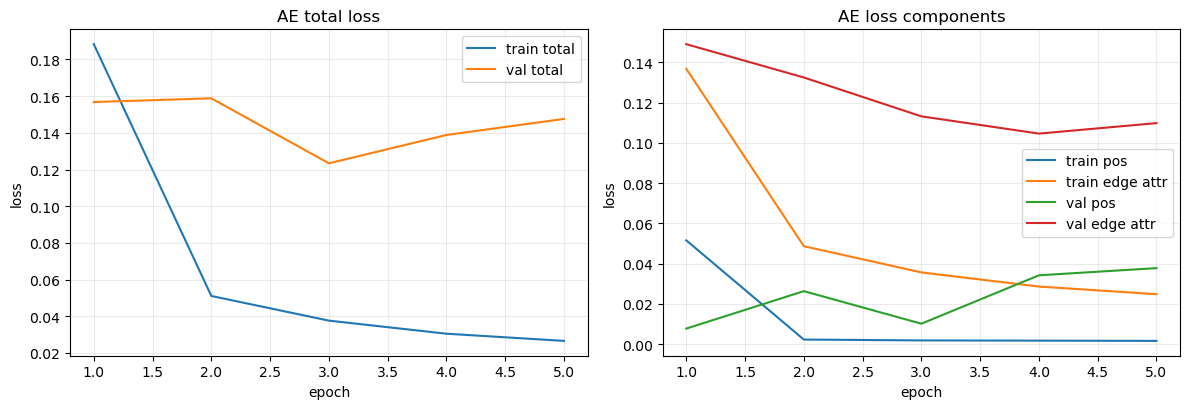

In [ ]:
if len(ae_train_total) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

    axes[0].plot(np.arange(1, len(ae_train_total) + 1), ae_train_total, label='train total')
    axes[0].plot(np.arange(1, len(ae_val_total) + 1), ae_val_total, label='val total')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].set_title('AE total loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(np.arange(1, len(ae_train_pos) + 1), ae_train_pos, label='train pos')
    axes[1].plot(np.arange(1, len(ae_train_edge_attr) + 1), ae_train_edge_attr, label='train edge attr')
    axes[1].plot(np.arange(1, len(ae_val_pos) + 1), ae_val_pos, label='val pos')
    axes[1].plot(np.arange(1, len(ae_val_edge_attr) + 1), ae_val_edge_attr, label='val edge attr')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss')
    axes[1].set_title('AE loss components')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.tight_layout()
    plt.show()



In [ ]:
model.eval()
essence_alpha = 0

final_pr = np.asarray([float(calc_p_ratio_box(sim, -1)) for sim in val_data], dtype=float)
aux_threshold = -0.3
non_threshold = 0.3

aux_idx = int(np.where(final_pr < aux_threshold)[0][0])
non_pool = np.where(final_pr > non_threshold)[0]
non_src_idx = int(non_pool[0])
non_tgt_idx = int(non_pool[1])

print('aux threshold:', aux_threshold, 'non threshold:', non_threshold)
print('essence_alpha:', essence_alpha)
print('aux_idx:', aux_idx, 'final p-ratio:', final_pr[aux_idx])
print('non_src_idx:', non_src_idx, 'final p-ratio:', final_pr[non_src_idx])
print('non_tgt_idx:', non_tgt_idx, 'final p-ratio:', final_pr[non_tgt_idx])

with torch.no_grad():
    g_aux = build_graph([val_data[aux_idx][0].to(device)]).to(device)
    g_non_src = build_graph([val_data[non_src_idx][0].to(device)]).to(device)
    g_non_tgt = build_graph([val_data[non_tgt_idx][0].to(device)]).to(device)

    z_aux = model.encode_latent(g_aux, is_training=False)
    z_non_src = model.encode_latent(g_non_src, is_training=False)
    z_non_tgt = model.encode_latent(g_non_tgt, is_training=False)

    # Auxetic essence in latent space.
    essence = z_aux - z_non_src
    z_edited = z_non_tgt + essence_alpha * essence

    recon_graph_non_tgt, _ = model.autoencode_graph(g_non_tgt, is_training=False)

    # Decode with the real target graph context so alpha=0 matches baseline.
    edited_graph = model.decode_graph_from_latent(g_non_tgt, z_edited, is_training=False)
    baseline_from_latent = model.decode_graph_from_latent(g_non_tgt, z_non_tgt, is_training=False)

x_mse_base = float(F.mse_loss(baseline_from_latent.x, recon_graph_non_tgt.x).item())
e_mse_base = float(F.mse_loss(baseline_from_latent.edge_attr, recon_graph_non_tgt.edge_attr).item())
x_mse_edit_vs_base = float(F.mse_loss(edited_graph.x, baseline_from_latent.x).item())
e_mse_edit_vs_base = float(F.mse_loss(edited_graph.edge_attr, baseline_from_latent.edge_attr).item())

print('z_aux:', z_aux.detach().cpu().numpy())
print('z_non_src:', z_non_src.detach().cpu().numpy())
print('z_non_tgt:', z_non_tgt.detach().cpu().numpy())
print('essence (z_aux - z_non_src):', essence.detach().cpu().numpy())
print('z_edited:', z_edited.detach().cpu().numpy())
print('recon edge_attr MSE:', float(F.mse_loss(recon_graph_non_tgt.edge_attr, g_non_tgt.edge_attr).item()))



print('alpha sanity x_mse decode(z_non_tgt) vs autoencode:', x_mse_base)
print('alpha sanity edge_mse decode(z_non_tgt) vs autoencode:', e_mse_base)
print('edited vs baseline x_mse:', x_mse_edit_vs_base)
print('edited vs baseline edge_mse:', e_mse_edit_vs_base)




print('decode uses target graph context (local skip stays consistent).')



aux threshold: -0.3 non threshold: 0.3
essence_alpha: 0
aux_idx: 1 final p-ratio: -0.5447152322559862
non_src_idx: 7 final p-ratio: 0.3579283810032026
non_tgt_idx: 11 final p-ratio: 0.35064449313376717
z_aux: [[-0.8450464   1.1695645  -0.05524729 -0.47417805 -1.3834788   0.6403005
   0.00620569 -0.5885097  -0.27052727  0.5938849  -0.86433125 -0.10334375
  -0.349097   -0.6200776  -0.46133745 -0.35822776 -0.38170922 -0.14350308
   0.89687717 -0.18026014  0.5655901  -0.09837329  0.6639513   0.03018759
   0.17417052 -0.8074972   0.88137937  0.43354267  0.21495977  0.09613581
   0.37920955  0.10082047 -0.1734062   0.2567872   0.06011595 -0.03917681
  -1.5423348   0.32152474 -0.1403129  -0.66823417 -0.1820252   0.2326301
   0.04681011 -0.2219597  -0.41445455 -0.10866316  0.29221177 -1.0565017
   0.3955387  -0.39087754  0.62689155  0.18898185 -0.719653   -0.5529629
   1.0014571  -0.89550036 -0.19850785 -0.03684944  0.62958527  0.00568578
   0.34265614  0.4982126   0.35178784  0.25778982 -0.38

Reference non-auxetic vs its AE reconstruction


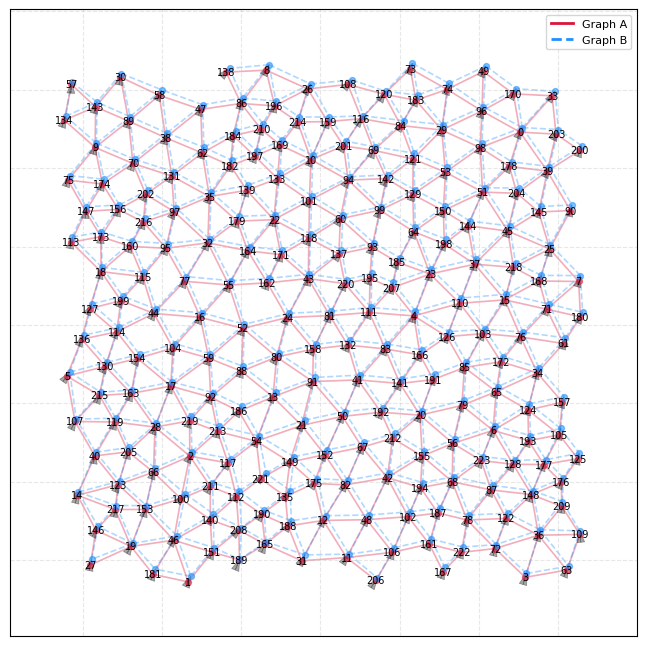

Reference non-auxetic vs edited (after adding auxetic essence)


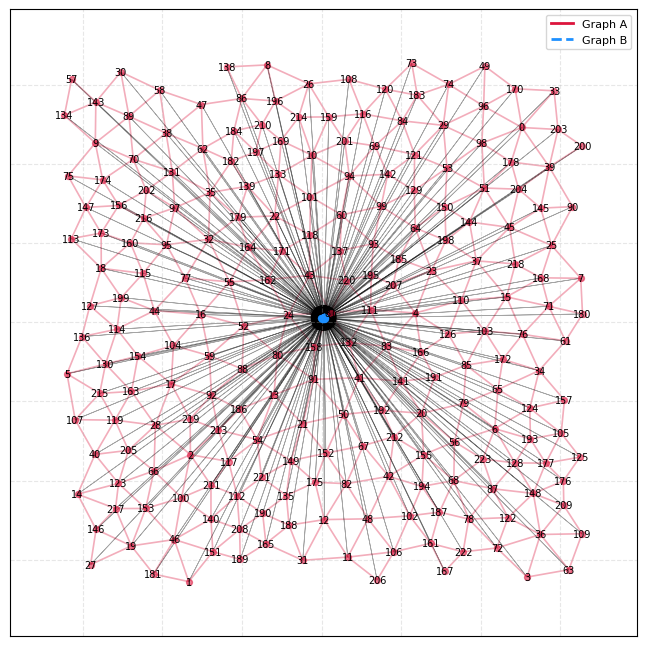

Auxetic reference vs edited


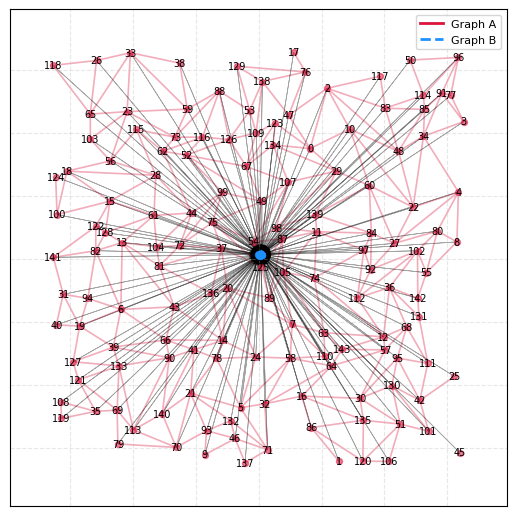

In [ ]:
g_non_tgt_ref = to_cpu_graph(g_non_tgt)
g_recon_non_tgt = to_cpu_graph(recon_graph_non_tgt)
g_edited = to_cpu_graph(edited_graph)
g_aux_ref = to_cpu_graph(g_aux)

G_non_tgt = pyg_to_networkx(g_non_tgt_ref, pos_slice=(0, cfg.pos_dim))
G_recon_non_tgt = pyg_to_networkx(g_recon_non_tgt, pos_slice=(0, cfg.pos_dim))
G_edited = pyg_to_networkx(g_edited, pos_slice=(0, cfg.pos_dim))
G_aux = pyg_to_networkx(g_aux_ref, pos_slice=(0, cfg.pos_dim))

print('Reference non-auxetic vs its AE reconstruction')
draw_graph_comparison(G_non_tgt, G_recon_non_tgt, show_displacement=True)

print('Reference non-auxetic vs edited (after adding auxetic essence)')
draw_graph_comparison(G_non_tgt, G_edited, show_displacement=True)

print('Auxetic reference vs edited')
draw_graph_comparison(G_aux, G_edited, show_displacement=True)

